# Part 1: Image Classification — Fashion‑MNIST (11 points)

**Goal:** Build and train a lightweight CNN on Fashion‑MNIST following the given architecture and specs.

LLM Usage (Queries) AI Disclosure:
1. How does random_split work? (used for defining train, val, test sets for both parts)
2. How would I use argmax in this context and what would I put for 'dimension'? (used in train_one_epoch and evaluate functions for both parts)
3. What does .to(device) do in Python and how would I use it? (used in train_one_epoch and evaluate functions for both parts)


Total CO2 usage: 4.32g * 3 queries = 12.96g

In [50]:
# import something you may find useful
import os, random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

# set seed
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# create a folder to save data
data_dir = "./data"
os.makedirs(data_dir, exist_ok=True)

Device: cpu


<div class="alert alert-success">
    <h3>1) Data</h3>
    load Fashion‑MNIST and create train/val/test splits (1 point)
</div>

In [51]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Use the following code to load the Fashion-MNIST if you want, or you can download the data manually
train_full = datasets.FashionMNIST(root=data_dir, train=True, download=True, transform=transform)
test_ds = datasets.FashionMNIST(root=data_dir, train=False, download=True, transform=transform)


In [52]:
# CODE HERE
# Define the training, validation, and test datasets. 
# Note that you may want to select the validation set from the training set by randomly splitting the data

#define train, validation, test dataest
train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size
train_ds, val_ds = random_split(train_full, [train_size, val_size])

batch_size = 64
# You may want to verify the data
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

len(train_ds), len(val_ds), len(test_ds)

(48000, 12000, 10000)

<div class="alert alert-success">
    <h3>2) Model</h3>
    Build the CNN model (3 points)
</div>

In [53]:
# Define the network architecture
class SmallCNN(nn.Module):
    def __init__(self):
        # CODE HERE
        # Define the convolutional layers, pooling layers...
        super().__init__()
        #First block
        self.conv1 = nn.Conv2d(1, 10, kernel_size = 3, padding = 1)
        self.pool1 = nn.MaxPool2d(2)
        # Second block
        self.conv2 = nn.Conv2d(10, 5, kernel_size = 3, padding = 1)
        # Third block
        self.conv3 = nn.Conv2d(5, 16, kernel_size = 3, padding = 1)
        self.pool2 = nn.MaxPool2d(2)

        #Connected FC after blocks
        flattened_size = 16*7*7 #after 2 2x2 pools, 28 to 14 to 7
        self.fc1 = nn.Linear(flattened_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 10)

    def forward(self, x):
        # CODE HERE
        # Implement the forward pass. Return the final output.
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        out = self.fc3(x)
        return out
        
        
# You may want to verify the architecture of CNN
model = SmallCNN().to(device)
model

SmallCNN(
  (conv1): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(10, 5, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(5, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=10, bias=True)
)

<div class="alert alert-success">
    <h3>3) Loss & Optimizer</h3>
    CrossEntropy + SGD (1 point)
</div>

In [54]:
# CODE HERE

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

# You may want to verify the criterion and optimizer
criterion, optimizer

(CrossEntropyLoss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.01
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

<div class="alert alert-success">
    <h3>4) Training loop</h3>
    track training and validation loss (1 points)
</div>

In [55]:
# CODE HERE
# Train the network for each epoch
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        #load images and labels to device (CPU)
        images = images.to(device) 
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images) # forward pass
        loss = criterion(outputs, labels) # cross-entropy
        loss.backward() # compute gradients
        optimizer.step()

        running_loss += loss.item() * images.size(0) # batch loss x batch size
        predicted = torch.argmax(outputs, dim = 1) # find index with highest score for each output in batch
        correct += (predicted == labels).sum().item() # how many are correct
        total += labels.size(0) #total examples seen

    #compute average loss and accuracy
    avg_loss = (running_loss / total)
    accuracy = (correct / total)

    return avg_loss, accuracy

# CODE HERE
# Evaluate the model on the validation set
@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        #load images and labels to device (CPU)
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images) # forward pass
        loss = criterion(outputs, labels) # cross-entropy

        running_loss += loss.item() * images.size(0) # batch loss x batch size
        predicted = torch.argmax(outputs, dim = 1) # find index with highest score for each output in batch
        correct += (predicted == labels).sum().item() # how many are correct
        total += labels.size(0) #total examples seen

    # compute average loss and accuracy
    avg_loss = (running_loss / total)
    accuracy = (correct / total)
    
    return avg_loss, accuracy

<div class="alert alert-success">
    <h3>5) Run training</h3>
    ≥ 15 epochs (1 point)
</div>

In [56]:
# CODE HERE
# Set the training epochs
epochs = 15 
train_losses, val_losses, train_accs, val_accs = [], [], [], []


# CODE HERE
# Run the training epochs
for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model, val_loader, criterion, device)

    # append to arrays
    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    train_accs.append(tr_acc)
    val_accs.append(va_acc)

    print(f"Epoch {epoch}: Train loss={tr_loss:.4f}, Train acc={tr_acc:.4f}, Val loss={va_loss:.4f}, Val acc={va_acc:.4f}") # testing

Epoch 1: Train loss=2.0261, Train acc=0.2313, Val loss=0.9990, Val acc=0.6118
Epoch 2: Train loss=0.8049, Train acc=0.6949, Val loss=0.6758, Val acc=0.7338
Epoch 3: Train loss=0.6119, Train acc=0.7695, Val loss=0.5821, Val acc=0.7766
Epoch 4: Train loss=0.5249, Train acc=0.8056, Val loss=0.5072, Val acc=0.8132
Epoch 5: Train loss=0.4810, Train acc=0.8248, Val loss=0.4807, Val acc=0.8229
Epoch 6: Train loss=0.4504, Train acc=0.8357, Val loss=0.4433, Val acc=0.8409
Epoch 7: Train loss=0.4251, Train acc=0.8433, Val loss=0.4561, Val acc=0.8342
Epoch 8: Train loss=0.4071, Train acc=0.8526, Val loss=0.4076, Val acc=0.8552
Epoch 9: Train loss=0.3936, Train acc=0.8563, Val loss=0.4097, Val acc=0.8537
Epoch 10: Train loss=0.3808, Train acc=0.8619, Val loss=0.3855, Val acc=0.8628
Epoch 11: Train loss=0.3679, Train acc=0.8658, Val loss=0.3722, Val acc=0.8669
Epoch 12: Train loss=0.3586, Train acc=0.8689, Val loss=0.3797, Val acc=0.8650
Epoch 13: Train loss=0.3513, Train acc=0.8719, Val loss=0.372

<div class="alert alert-success">
    <h3>6) Plot</h3>
    training vs validation loss (1 point)
</div>

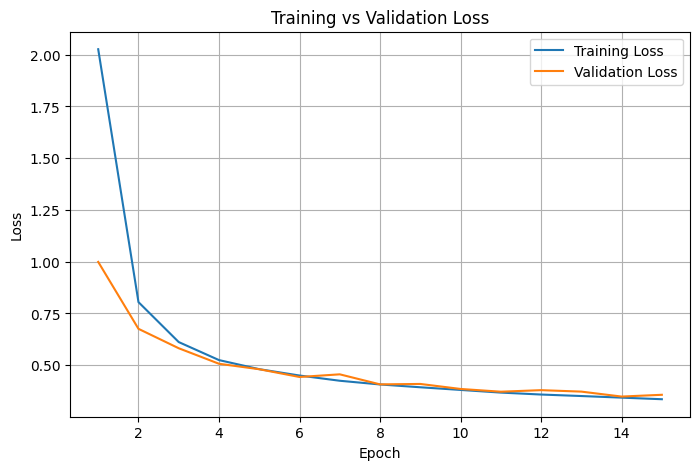

In [57]:
# CODE HERE
# Plot the "Training vs Validation Loss"

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

<div class="alert alert-success">
    <h3>7) Evaluate on test set</h3>
    report accuracy on test set. Then report the model performance by showing the test accuracy (1 point)
</div>

In [58]:
# CODE HERE
# Test the model on the test set

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"[Fashion-MNIST test] Loss = {test_loss:.4f} | Acc = {test_acc*100:.2f}%")

[Fashion-MNIST test] Loss = 0.3622 | Acc = 86.83%


<div class="alert alert-success">
    <h3>8) Discussion prompts (2 point)</h3>
    (a) Which techniques from Table 3 report better performance than your method? Which performs worse? Why do you think this is the case? Briefly explain. (1 point)<br>
    (b) Do you have any other ideas about how to improve your method? Briefly explain. (1 point)
</div>

Discussion Prompt Answers

(a) Several techniques in Table 3 achieve higher Fashion‑MNIST accuracy than my CNN (86.83%), including the best SVC models (with RBF or polynomial kernels), Gradient Boosting, Random Forests, KNN, and some MLP configurations, which reach roughly 87–90% test accuracy. Many other methods perform worse, such as decision trees, Extra Trees, Gaussian Naive Bayes, basic Perceptron/SGD/Passive‑Aggressive classifiers, which mostly stay in the 50–82% range. 
The better performing methods use non‑linear decision making as well as complex architectures, while the worse performing methods are either too simple or too linear to fully predict the images in Fashion‑MNIST. My small CNN sits in between, using a more complex structure than the weaker models in Table 3, but not as intricate with the extra capacity or architecture of the better methods.

(b) One way to improve my method could be to tune SGD by tuning the hyperparameter for learning rate (potentially GridSearchCV) as well as potentially adding momentum, which could helps the CNN to approach a better prediction for image tasks like Fashion‑MNIST. Another idea is to slightly increase the capacity of the network (for example, widening the fully connected layers) and adding dropout after these layers to reduce overfitting. This can allow the model to learn more in depth features while reducing memorization of the training data. Dropout is implemented in Part 2 of this assignment which led me to believe it would likely help in Part 1 as well.

# Part 2: Image Classification — CIAFR-100 (14 points)

**Goal:** Build and train a lightweight CNN on CIAFR-100 following the given architecture and specs.

In [59]:
# import something you may find useful
import os, random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision import datasets, transforms
import numpy as np

import matplotlib
import matplotlib.pyplot as plt


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

data_dir = "./data"
os.makedirs(data_dir, exist_ok=True)


Device: cpu


<div class="alert alert-success">
    <h3>1) Data</h3>
    load CIFAR-100 and create train/val/test splits (1 point)
</div>

In [60]:
# CIFAR-100 normalization stats
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

# Load CIFAR-100 (train + test)
# Use the following code to load the CIFAR-100 if you want, or you can download the data manually
train_full = datasets.CIFAR100(root=data_dir, train=True,  download=True, transform=transform)
test_ds = datasets.CIFAR100(root=data_dir, train=False, download=True, transform=transform)



In [61]:
# CODE HERE
# Define the training, validation, and test datasets. 
# Note that you may want to select the validation set from the training set by randomly splitting the data

train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size
train_ds, val_ds = random_split(train_full, [train_size, val_size])

batch_size = 64
# You may want to verify the data
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

len(train_ds), len(val_ds), len(test_ds)

(40000, 10000, 10000)

<div class="alert alert-success">
    <h3>2) Model</h3>
    Build the CNN model (4 points)
</div>

In [62]:
# Define the network architecture
class SmallCNN(nn.Module):
    def __init__(self):
        # CODE HERE
        # Define the convolutional layers, pooling layers...
        super().__init__()
        # First block
        self.conv1 = nn.Conv2d(3, 16, kernel_size = 3, padding = 1) # input channels = 3
        self.pool1 = nn.MaxPool2d(2)
        # Second block
        self.conv2 = nn.Conv2d(16, 32, kernel_size = 3, padding = 1)
        # Third block
        self.conv3 = nn.Conv2d(32, 16, kernel_size = 3, padding = 1) # input channels = 3
        self.pool2 = nn.MaxPool2d(2)
        self.dropout_conv = nn.Dropout(p=0.2)
        # Connected FC after blocks
        flattened_size = 16*8*8 #after 2 2x2 pools, 32 to 16 to 8
        self.fc1 = nn.Linear(flattened_size, 128)
        self.fc2 = nn.Linear(128, 100) # output 100 classes for CIFAR
        self.dropout_fc = nn.Dropout(p=0.2)

    def forward(self, x):
        # CODE HERE
        # Implement the forward pass. Return the final output.
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool2(x)
        x = self.dropout_conv(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        out = self.dropout_fc(x)

        return out
     
# You may want to verify the architecture of CNN
model = SmallCNN().to(device)
model

SmallCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout_conv): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=1024, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=100, bias=True)
  (dropout_fc): Dropout(p=0.2, inplace=False)
)

<div class="alert alert-success">
    <h3>3) Loss & Optimizer</h3>
    CrossEntropy + SGD (1 point)
</div>

In [63]:
# CODE HERE

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

# You may want to verify the criterion and optimizer
criterion, optimizer

(CrossEntropyLoss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.1
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

<div class="alert alert-success">
    <h3>4) Training loop</h3>
    track training and validation loss (1 points)
</div>

In [64]:
# CODE HERE
# Train the network for each epoch
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        #load images and labels to device (CPU)
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images) #forward pass
        loss = criterion(outputs, labels) # cross-entropy
        loss.backward() # compute gradients
        optimizer.step()

        running_loss += loss.item() * images.size(0) # batch loss x batch size
        predicted = torch.argmax(outputs, dim=1) # find index with highest score for each output in batch
        correct += (predicted == labels).sum().item() #how many correct
        total += labels.size(0) # total examples seen

    # compute average loss and accuracy
    avg_loss = (running_loss / total)
    accuracy = (correct / total)

    return avg_loss, accuracy

# CODE HERE
# Evaluate the model on the validation set
@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        #load images and labels to device (CPU)
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images) # forward pass
        loss = criterion(outputs, labels) # cross-entropy

        running_loss += loss.item() * images.size(0) # batch loss x batch size
        predicted = torch.argmax(outputs, dim = 1) # find index with highest score for each output in batch
        correct += (predicted == labels).sum().item() #how many correct
        total += labels.size(0) # total examples seen

    # compute average loss and accuracy
    avg_loss = (running_loss / total)
    accuracy = (correct / total)

    return avg_loss, accuracy


<div class="alert alert-success">
    <h3>5) Run training</h3>
    ≥ 15 epochs (1 point)
</div>

In [65]:
# CODE HERE
# Set the training epochs
epochs = 15
train_losses, val_losses, train_accs, val_accs = [], [], [], []

# CODE HERE
# Run the training epochs
for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model, val_loader, criterion, device)
    
    # append to arrays
    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    train_accs.append(tr_acc)
    val_accs.append(va_acc)

    print(f"Epoch {epoch}: Train loss={tr_loss:.4f}, Train acc={tr_acc:.4f}, Val loss={va_loss:.4f}, Val acc={va_acc:.4f}") # testing



Epoch 1: Train loss=4.3292, Train acc=0.0522, Val loss=3.9350, Val acc=0.0919
Epoch 2: Train loss=3.9012, Train acc=0.1193, Val loss=3.6194, Val acc=0.1565
Epoch 3: Train loss=3.6473, Train acc=0.1690, Val loss=3.3245, Val acc=0.2147
Epoch 4: Train loss=3.4561, Train acc=0.2051, Val loss=3.1056, Val acc=0.2500
Epoch 5: Train loss=3.2834, Train acc=0.2407, Val loss=2.9249, Val acc=0.2857
Epoch 6: Train loss=3.1564, Train acc=0.2636, Val loss=2.9079, Val acc=0.2834
Epoch 7: Train loss=3.0578, Train acc=0.2856, Val loss=2.8473, Val acc=0.2979
Epoch 8: Train loss=2.9722, Train acc=0.3046, Val loss=2.7413, Val acc=0.3271
Epoch 9: Train loss=2.9088, Train acc=0.3174, Val loss=2.7221, Val acc=0.3186
Epoch 10: Train loss=2.8328, Train acc=0.3330, Val loss=2.7306, Val acc=0.3207
Epoch 11: Train loss=2.7920, Train acc=0.3438, Val loss=2.6737, Val acc=0.3396
Epoch 12: Train loss=2.7346, Train acc=0.3561, Val loss=2.6349, Val acc=0.3386
Epoch 13: Train loss=2.6862, Train acc=0.3658, Val loss=2.667

<div class="alert alert-success">
    <h3>6) Plot</h3>
    training vs validation loss (1 point)
</div>

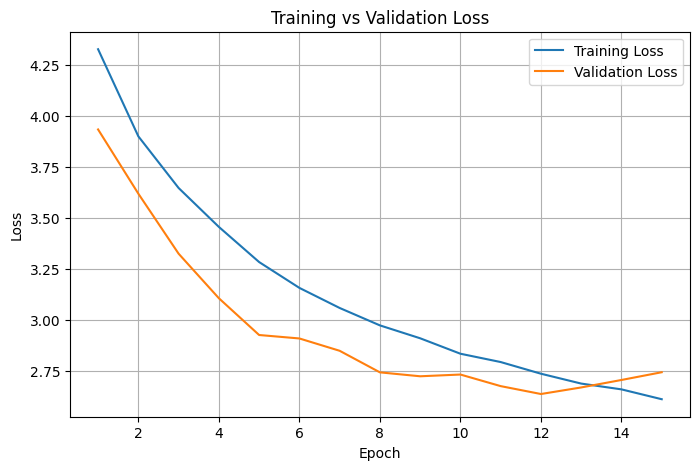

In [66]:
# CODE HERE

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

<div class="alert alert-success">
    <h3>7) Evaluate on test set</h3>
    report accuracy (1 point)
</div>

In [67]:
# CODE HERE
# Test the model on the test set

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"[CIFAR-100 test] Loss = {test_loss:.4f} | Acc = {test_acc*100:.2f}%")

[CIFAR-100 test] Loss = 2.7240 | Acc = 33.10%


<div class="alert alert-success">
    <h3>8) Discussion prompts (4 points)</h3>
    (a) Compared to your Fashion-MNIST results in Part 1, how did the training and validation curves change on CIFAR-100? Did you observe more overfitting, underfitting, or slower convergence? Explain briefly. (1 point)<br>
    (b) Based on the ResNet results above (around $80\%$ accuracy) and your own results (around $35$-$45\%$), what architectural differences do you think account for most of the performance gap? Consider depth, width (number of channels), skip connections, and data augmentation, and any modifications you have made to your own architecture. (2 point)<br>
    (c) What change did you make to your architecture that you were most surprised about?
This could be a large increase or decrease in performance, or something you added that
didn’t change anything. What is your big takeaway from that experience? (1 point)<br>
    
</div>

Discussion Prompt Answers

(a) On Fashion‑MNIST, both training and validation loss decreased smoothly and stayed close together, with the model reaching about 84-87% test accuracy and only mild overfitting near the end of training. On CIFAR‑100, the dataset experienced more overfitting than the Fashion-MNIST results. The reason for this occurence is likely that there are many more samples per class in Fashion-MNIST than the CIFAR-100 datasets. Additionally, CIFAR-100 images are far more complex since they are color images with varied textures, objects, and backgrounds, whereas Fashion-MNIST images are grayscale and simple. This makes it easier for the model to learn from the data resulting in less overfitting as compared to CIFAR-100. 

(b) The ResNet that reaches around 80% accuracy on CIFAR‑100 is much deeper and wider than the SmallCNN used in this assignment, with many more convolutional layers, many more channels in each layer, and residual (skip) connections that help train very deep networks without vanishing gradients. In contrast, the SmallCNN for this assignment has only three convolutional layers with relatively few channels and only light regularization and augmentation, so it cannot learn as well as the ResNet which explains most of the gap between roughly 32-36% (assignment PDF states 30% is least amount necessary) accuracy and 80%+. In terms of optimizing this architecture, initially the CIFAR-100 dataset was run with a very similar architecture to the Fashion-MNIST. However, it reached a very low 8-11% accuracy. To modify, I removed a linear layer to 'skip' some depths and introduced dropout to better train the model and prevent overfitting. This brought my accuracy up to 27%. The remaining 5% was added by additionally widening the number of channels to allow for more capacity.

(c) the change that surprised me most was that removing one of the linear layers in the fully connected head made accuracy jump from about 8–11% up to roughly 27%. Instead of hurting performance, this modification made the network much easier to optimize. There were many parameters packed at the end, so plain SGD with a fairly high learning rate struggled to find good weights and the model underfit badly. Collapsing the head to a single hidden layer seemed to shorten the path from conv features to logits and reduced the number of poorly conditioned parameters. This might have caused gradients to be more effective and the CNN could learn useful features. My main takeaway is that more layers are not always better, especially in the fully connected part of a small CNN. For this CIFAR‑100 model, a deeper classifier actually made optimization harder and caused very low accuracy, while a simpler head with fewer linear layers trained more reliably and used the convolutional features more effectively, giving a much larger accuracy gain than tweaks like small dropout or data augmentation.
